### This notebook takes in features from the data to train a model that can accurately rank customers in different tier buckets based on their lifetime value with the business

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/model_features.parquet")
df.sample(5)

,customer_id,transaction_count,promo_usage_count,quantity,avg_order_value,first_purchase_date,last_purchase_date,purchase_recency,customer_tenure,payment_method_count,future_spend,total_spent,log_future_spend,will_spend,avg_qty_per_txn,spend_velocity,txn_frequency,promo_ratio,recency_ratio,payment_diversity
19445,79004,3,1,6,34.084,2021-03-30 15:39:00,2021-11-29 18:54:00,32.211817,276.347558,2,5.567,102.251,1.882057,1,2.0,0.370009,0.010856,0.333333,0.116563,0.666667
3547,11473,1,0,1,20.291,2021-06-20 23:47:00,2021-06-20 23:47:00,194.008760,194.008760,1,44.770,20.291,3.823629,1,1.0,0.104588,0.005154,0.000000,1.000000,1.000000
11775,69989,2,1,7,83.578,2021-07-15 14:54:00,2021-10-19 14:33:00,73.393291,169.378997,1,30.580,501.468,3.452524,1,3.5,2.960627,0.011808,0.500000,0.433308,0.500000
19119,71424,6,11,15,81.643,2021-02-07 15:59:00,2021-11-28 19:25:00,33.190418,327.333462,1,179.994,1224.647,5.198464,1,2.5,3.741283,0.018330,1.833333,0.101396,0.166667
2455,72513,1,1,1,15.303,2021-05-17 05:04:00,2021-05-17 05:04:00,228.788334,228.788334,1,0.000,15.303,0.000000,0,1.0,0.066887,0.004371,1.000000,1.000000,1.000000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36086 entries, 0 to 36085
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           36086 non-null  int64         
 1   transaction_count     36086 non-null  int64         
 2   promo_usage_count     36086 non-null  int64         
 3   quantity              36086 non-null  int64         
 4   avg_order_value       36086 non-null  float64       
 5   first_purchase_date   36086 non-null  datetime64[ns]
 6   last_purchase_date    36086 non-null  datetime64[ns]
 7   purchase_recency      36086 non-null  float64       
 8   customer_tenure       36086 non-null  float64       
 9   payment_method_count  36086 non-null  int64         
 10  future_spend          36086 non-null  float64       
 11  total_spent           36086 non-null  float64       
 12  log_future_spend      36086 non-null  float64       
 13  will_spend      

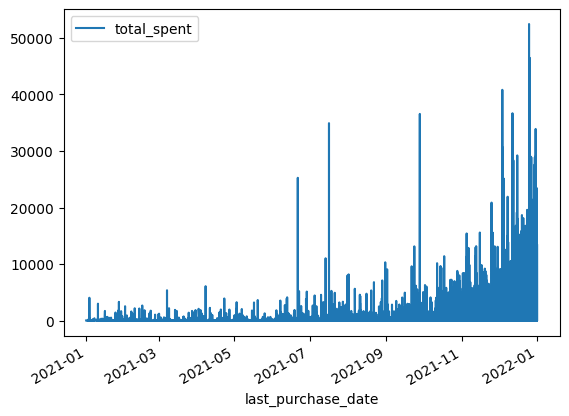

In [3]:
df.plot(x="last_purchase_date", y="total_spent")
plt.show()

__We'll be setting up transformers inside a pipeline instead of doing it openly (helps avoid possible data leakage)__

<Axes: >

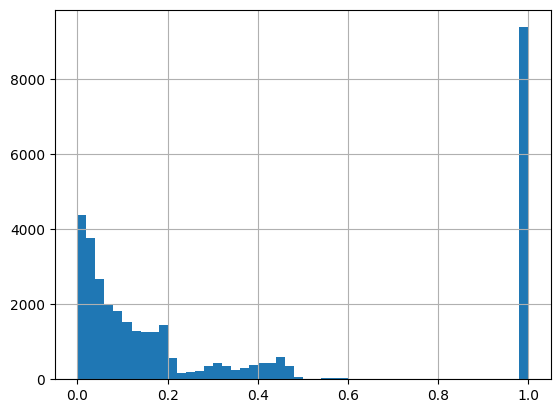

In [4]:
df["recency_ratio"].hist(bins=50)

In [5]:
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Features that are right-skewed and should be log transformed + scaled
log_features = [
    'transaction_count', 'quantity', 'total_spent',
    'customer_tenure', 'purchase_recency',
    'avg_qty_per_txn', 'spend_velocity'
]

# Features that just need scaling
scale_features = [
    'payment_method_count', 'promo_usage_count',
    'txn_frequency', 'promo_ratio', 'recency_ratio', 'payment_diversity'
]

log_transformer = Pipeline(steps=[
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

scale_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("log_features", log_transformer, log_features),
        ("scale_features", scale_transformer, scale_features),
    ]
)

### Seperating features from target variable

In [6]:
X = df.drop(columns=["future_spend", "last_purchase_date"])
y = df["future_spend"]

In [7]:
X.sample(5)

,customer_id,transaction_count,promo_usage_count,quantity,avg_order_value,first_purchase_date,purchase_recency,customer_tenure,payment_method_count,total_spent,log_future_spend,will_spend,avg_qty_per_txn,spend_velocity,txn_frequency,promo_ratio,recency_ratio,payment_diversity
14258,46963,1,0,1,19.677,2021-11-06 03:36:00,55.849961,55.849961,1,19.677,4.597269,1,1.000000,0.352319,0.017905,0.000000,1.000000,1.000000
33972,57521,20,5,46,50.803,2021-01-02 00:40:00,2.801925,363.971716,3,1727.311,5.456521,1,2.300000,4.745729,0.054949,0.250000,0.007698,0.150000
32937,26143,14,5,28,43.993,2021-01-23 16:27:00,4.109275,342.313986,3,747.876,4.810353,1,2.000000,2.184766,0.040898,0.357143,0.012004,0.214286
31125,14079,2,0,2,18.798,2021-05-22 18:02:00,6.203182,223.248495,1,37.596,0.000000,0,1.000000,0.168404,0.008959,0.000000,0.027786,0.500000
27336,22027,13,9,25,29.826,2021-01-08 17:25:00,12.115898,357.273641,2,447.392,5.481572,1,1.923077,1.252239,0.036387,0.692308,0.033912,0.153846


In [8]:
y.describe()

count    36086.000000
mean       135.517851
std        227.197064
min          0.000000
25%          0.000000
50%         42.775000
75%        167.486250
max       3069.269000
Name: future_spend, dtype: float64

<hr/>

#### <h3 style = "text-align:center;"> Splitting the data (Time Series Split) </h3>

TimeSeriesSplit is used because it maintains the date order and gives multiple train-test folds. <br/> We'll be using the walk-forward cross-validation technique to evaluate on different train-test folds



In [9]:

from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    n_jobs=4,
    objective='reg:quantileerror',      # boosts prediction accuracy of higher value customers
    quantile_alpha=0.8,     # model focuses on predicting the 80th quantile
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    )

time_series_split = TimeSeriesSplit(n_splits=6)

<hr/>


#### <h3 style = "text-align:center;"> Evaluating Model Performance </h3>

You can say there we will evaluate the model's performance in two ways:
1. How far its predictions are from the actual value of a customer's future spend
2. How well the model is able to group customers into tiers (High, Mid, low) based on value provided to the business


In [10]:

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# We'll collect metrics for each fold and average it to get the overall performance
mae_scores = []
rmse_scores = []
fold_stats = []

for fold, (train_index, valid_index) in enumerate(time_series_split.split(X)):
    # Walk-forward timesplit cross-validation
    X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]



    y_train_log = np.log1p(y_train)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor), # our preprocessor pipeline (log and scaling)
        ("model", xgb)])    # data is now fitted into our xgboost model

    pipeline.fit(X_train, y_train_log)  # train on LOG-TRANSFORMED target

    # Runs prediction on the validation set (predictions are in log-space)
    preds_log = pipeline.predict(X_valid)

    # === KEY CHANGE: Inverse-transform predictions back to original scale ===
    preds = np.expm1(preds_log)         # reverse the log1p transform
    preds = np.maximum(preds, 0)        # clamp negatives to 0 (spend can't be negative)

    # Evaluate on ORIGINAL scale (so metrics are comparable to before)
    mae  = mean_absolute_error(y_valid, preds)
    rmse = root_mean_squared_error(y_valid, preds)

    mae_scores.append(mae)
    rmse_scores.append(rmse)

    # Collect descriptive stats for validation set
    valid_stats = {
        'fold': fold,
        'count': y_valid.count(),
        'mean': y_valid.mean(),
        'median': y_valid.median(),
        'std': y_valid.std(),
        'min': y_valid.min(),
        'max': y_valid.max(),
        'q25': y_valid.quantile(0.25),
        'q75': y_valid.quantile(0.75),
        'mae': mae,
        'rmse': rmse
    }
    fold_stats.append(valid_stats)

    print("=======================================")
    print(f"Fold {fold}")
    print(f"Train period: {X_train.index.min()} → {X_train.index.max()}")
    print(f"Valid period: {X_valid.index.min()} → {X_valid.index.max()}\n")
    print("Validation Set Statistics:")
    print(f"  Count: {y_valid.count()}")
    print(f"  Mean: {y_valid.mean():.2f}")
    print(f"  Median: {y_valid.median():.2f}")
    print(f"  Std Dev: {y_valid.std():.2f}")
    print(f"  Min: {y_valid.min():.2f}")
    print(f"  Max: {y_valid.max():.2f}")
    print(f"  Q1 (25%): {y_valid.quantile(0.25):.2f}")
    print(f"  Q3 (75%): {y_valid.quantile(0.75):.2f}\n")
    print(f"MAE for fold: {mae:.2f}")
    print(f"RMSE for fold: {rmse:.2f}")


print("\n" + "="*40)
print("Average performance")
print("="*40)
print(f"Average MAE across all folds : {np.mean(mae_scores):.2f}")
print(f"Average RMSE across all folds: {np.mean(rmse_scores):.2f}")


stats_df = pd.DataFrame(fold_stats)     # showing results summary in a dataframe
print("\nDetailed Stats by Fold:")
print(stats_df.to_string())



Fold 0
Train period: 0 → 5155
Valid period: 5156 → 10310

Validation Set Statistics:
  Count: 5155
  Mean: 23.26
  Median: 9.12
  Std Dev: 48.62
  Min: 0.00
  Max: 774.01
  Q1 (25%): 0.00
  Q3 (75%): 25.06

MAE for fold: 32.43
RMSE for fold: 58.41
Fold 1
Train period: 0 → 10310
Valid period: 10311 → 15465

Validation Set Statistics:
  Count: 5155
  Mean: 49.20
  Median: 26.19
  Std Dev: 72.22
  Min: 0.00
  Max: 939.76
  Q1 (25%): 0.00
  Q3 (75%): 61.99

MAE for fold: 50.12
RMSE for fold: 84.05
Fold 2
Train period: 0 → 15465
Valid period: 15466 → 20620

Validation Set Statistics:
  Count: 5155
  Mean: 84.40
  Median: 52.64
  Std Dev: 102.14
  Min: 0.00
  Max: 1308.59
  Q1 (25%): 14.39
  Q3 (75%): 115.63

MAE for fold: 70.03
RMSE for fold: 98.90
Fold 3
Train period: 0 → 20620
Valid period: 20621 → 25775

Validation Set Statistics:
  Count: 5155
  Mean: 150.73
  Median: 108.10
  Std Dev: 153.04
  Min: 0.00
  Max: 1414.49
  Q1 (25%): 38.41
  Q3 (75%): 214.55

MAE for fold: 87.03
RMSE for f

You can check out future spend over time but visualized, it shows the trend the model is working with and its MAE over time:

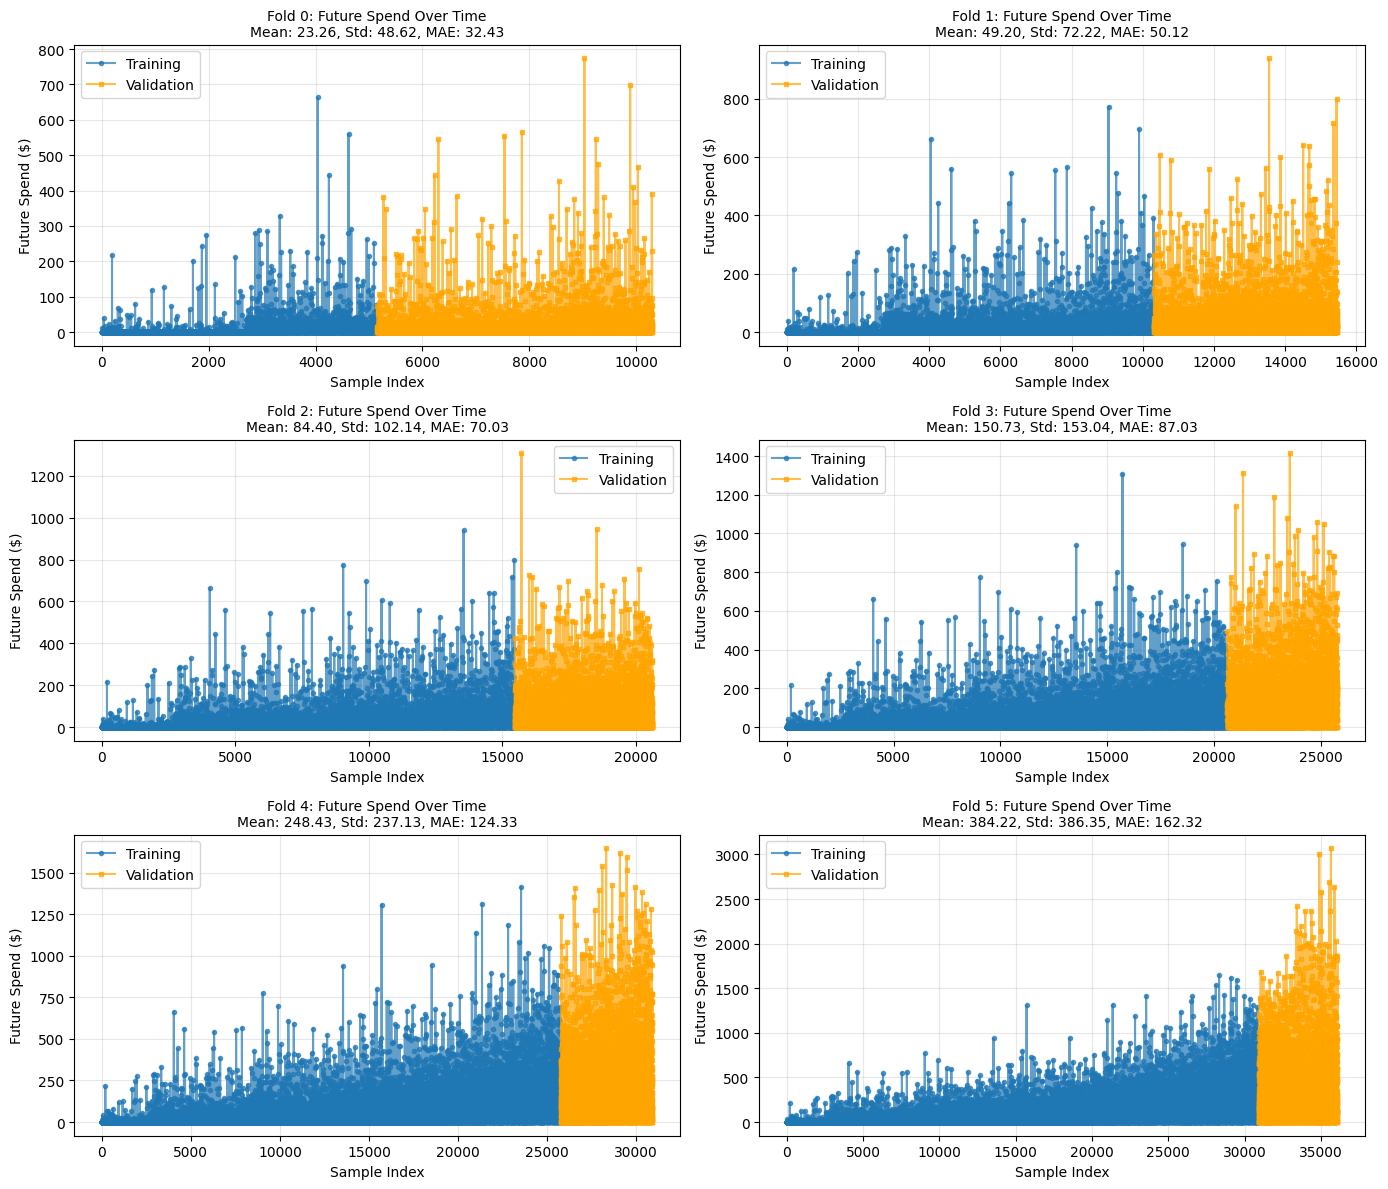

In [11]:

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for fold, (train_index, valid_index) in enumerate(time_series_split.split(X)):
    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]
    
    ax = axes[fold]
    
    # Plot training and validation data
    ax.plot(y_train.index, y_train.values, label='Training', alpha=0.7, marker='o', markersize=3)
    ax.plot(y_valid.index, y_valid.values, label='Validation', alpha=0.7, marker='s', markersize=3, color='orange')
    
    ax.set_title(f'Fold {fold}: Future Spend Over Time\nMean: {y_valid.mean():.2f}, Std: {y_valid.std():.2f}, MAE: {fold_stats[fold]["mae"]:.2f}', fontsize=10)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Future Spend ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

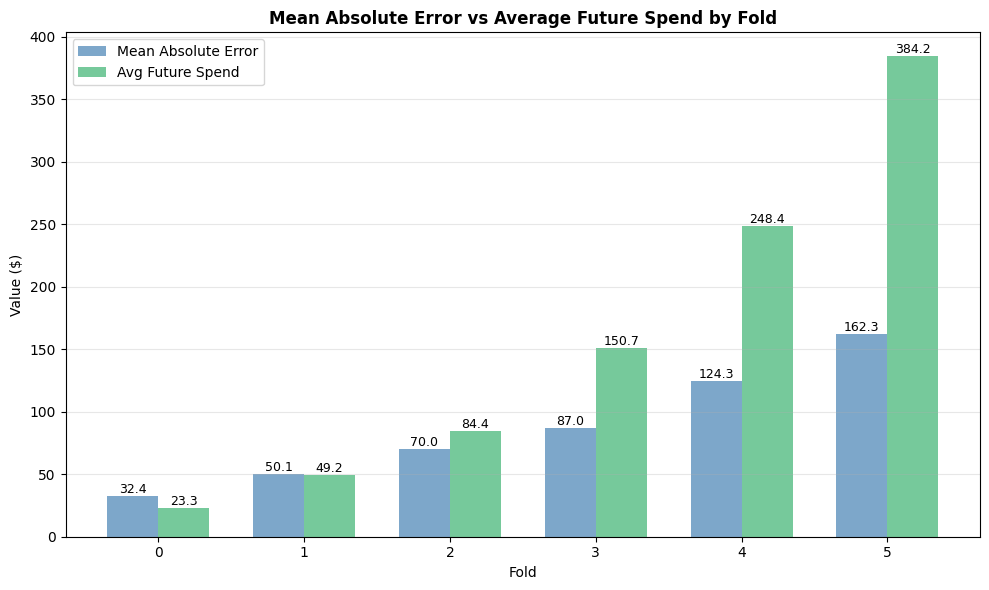

In [12]:
# Comparative analysis: Average Future Spend vs MAE per fold
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(stats_df['fold']))
width = 0.35

bars1 = ax.bar(x - width/2, stats_df['mae'], width, label='Mean Absolute Error', color='steelblue', alpha=0.7)
bars2 = ax.bar(x + width/2, stats_df['mean'], width, label='Avg Future Spend', color='mediumseagreen', alpha=0.7)

# Add data labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9)

ax.set_title('Mean Absolute Error vs Average Future Spend by Fold', fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('Value ($)')
ax.set_xticks(x)
ax.set_xticklabels(stats_df['fold'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


<hr/>

In [13]:
df[["total_spent", "future_spend"]].describe()

,total_spent,future_spend
count,36086.000000,36086.000000
mean,708.793996,135.517851
std,1759.728243,227.197064
min,1.635000,0.000000
25%,33.018000,0.000000
50%,130.647500,42.775000
75%,576.420000,167.486250
max,52428.261000,3069.269000


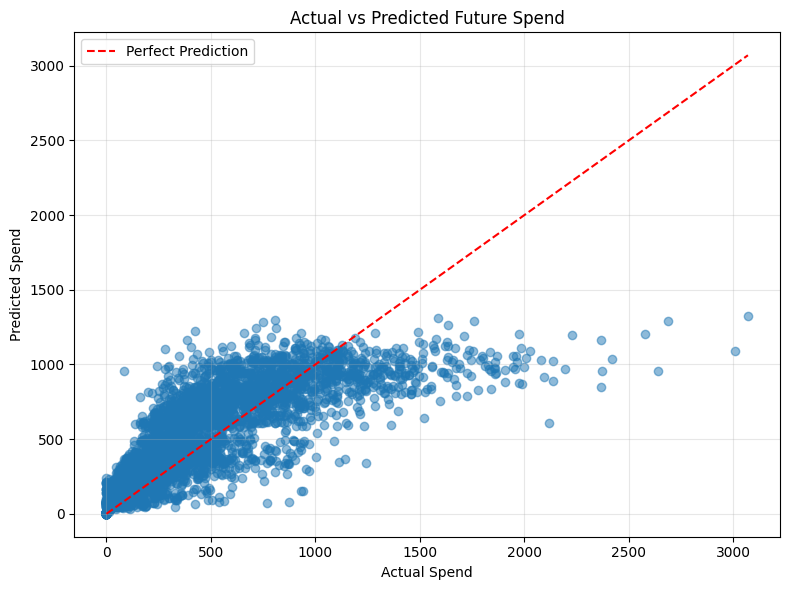

In [14]:
df_results = pd.DataFrame({'actual_spend': y_valid, 'predicted_spend': preds})

plt.figure(figsize=(8, 6))
plt.scatter(df_results['actual_spend'], df_results['predicted_spend'], alpha=0.5)
plt.plot([df_results['actual_spend'].min(), df_results['actual_spend'].max()],
         [df_results['actual_spend'].min(), df_results['actual_spend'].max()],
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Spend')
plt.ylabel('Predicted Spend')
plt.title('Actual vs Predicted Future Spend')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

__The model's predictions are less accurate for higher transaction amounts.__ <br/>
__Our main ain is for the model to be able to properly group customers into high, mid and low value.__<br/>
__The accuracy of its grouping will depend on how accurate its actual value predictions are. So there is some room for variance as long as it is properly grouped__

In [15]:

high_cutoff = df_results['actual_spend'].quantile(0.80)
mid_cutoff = df_results['actual_spend'].quantile(0.50)

print(f"High Value Threshold: ${high_cutoff:.2f}")
print(f"Mid Value Threshold: ${mid_cutoff:.2f}")

def assign_tier(value, high, mid):
    if value >= high:
        return 'High'
    elif value >= mid:
        return 'Mid'
    else:
        return 'Low'

df_results['actual_tier'] = df_results['actual_spend'].apply(lambda x: assign_tier(x, high_cutoff, mid_cutoff))
df_results['predicted_tier'] = df_results['predicted_spend'].apply(lambda x: assign_tier(x, high_cutoff, mid_cutoff))

# Calculate and display distributions
for col in ['actual_tier', 'predicted_tier']:
    print(f"\n{col.replace('_', ' ').title()} Distribution:")
    counts = df_results[col].value_counts()
    pcts = df_results[col].value_counts(normalize=True) * 100
    print(pd.concat([counts, pcts], axis=1, keys=['Count', 'Percentage (%)']).round(2))

df_results.sample(5)

High Value Threshold: $651.23
Mid Value Threshold: $261.76

Actual Tier Distribution:
             Count  Percentage (%)
actual_tier                       
Low           2577           49.99
Mid           1547           30.01
High          1031           20.00

Predicted Tier Distribution:
                Count  Percentage (%)
predicted_tier                       
Mid              1862           36.12
Low              1792           34.76
High             1501           29.12


,actual_spend,predicted_spend,actual_tier,predicted_tier
34741,392.873,615.196167,Mid,Mid
35133,385.069,772.140808,Mid,High
30944,519.431,961.620178,Mid,High
34595,1226.900,1117.985107,High,High
33617,802.107,846.222961,High,High


In [16]:

tier_stats = df_results.groupby('actual_tier').apply(lambda x: pd.Series({
    'correct': (x['actual_tier'] == x['predicted_tier']).sum(),
    'total': len(x)
}))

print("Model Tiering Accuracy per Tier:")
for tier, row in tier_stats.iterrows():
    accuracy = (row['correct'] / row['total']) * 100
    print(f"Tier {tier}: {int(row['correct'])} / {int(row['total'])} ({accuracy:.2f})%")



print("\n ==============================================\n")
# Breakdown of misclassified High-tier customers
high_tier = df_results[df_results['actual_tier'] == 'High']
misclassified_high = high_tier[high_tier['predicted_tier'] != 'High']

total_high = len(high_tier)
total_misclassified = len(misclassified_high)

mis_as_mid = (misclassified_high['predicted_tier'] == 'Mid').sum()
mis_as_low = (misclassified_high['predicted_tier'] == 'Low').sum()

print(f"High-Tier Customers: {total_high}")
print(f"Misclassified: {total_misclassified} ({total_misclassified/total_high*100:.2f}%)")
print(f"  → Predicted as Mid: {mis_as_mid} ({mis_as_mid/total_misclassified*100:.2f}% of misclassified)")
print(f"  → Predicted as Low: {mis_as_low} ({mis_as_low/total_misclassified*100:.2f}% of misclassified)")


Model Tiering Accuracy per Tier:
Tier High: 907 / 1031 (87.97)%
Tier Low: 1693 / 2577 (65.70)%
Tier Mid: 881 / 1547 (56.95)%


High-Tier Customers: 1031
Misclassified: 124 (12.03%)
  → Predicted as Mid: 119 (95.97% of misclassified)
  → Predicted as Low: 5 (4.03% of misclassified)


In [17]:
correct_predictions = (df_results['actual_tier'] == df_results['predicted_tier']).sum()
total_predictions = len(df_results)
accuracy = (correct_predictions / total_predictions) * 100

print(f"Total Correct Tier Assignments: {correct_predictions} / {total_predictions}")
print(f"Overall Tier Accuracy: {accuracy:.2f}%")

Total Correct Tier Assignments: 3481 / 5155
Overall Tier Accuracy: 67.53%


This next plot is an analysis of __actual future spend__. So it shows us how much eah customer segment actually made us in the future (prediction window for the model), which is 7 months into the new year (2022)

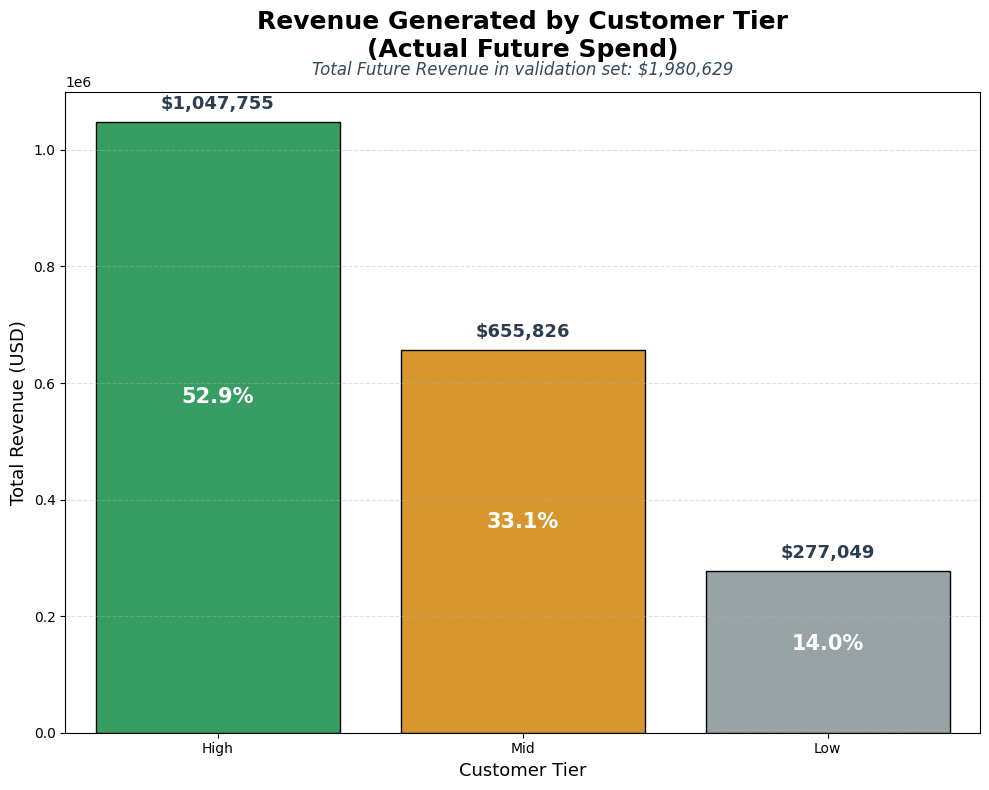

In [18]:


revenue_df = df_results.groupby('actual_tier').agg(
    total_revenue=('actual_spend', 'sum'),
    customer_count=('actual_spend', 'count')
).reset_index()

total_revenue = revenue_df['total_revenue'].sum()
revenue_df['percent_of_total'] = (revenue_df['total_revenue'] / total_revenue * 100).round(1)

# Tiers by revenue amount (descending)
revenue_df = revenue_df.sort_values('total_revenue', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))

tier_colors = {'High': '#27ae60', 'Mid': '#f39c12', 'Low': '#95a5a6'}

ax = sns.barplot(
    data=revenue_df,
    x='actual_tier',
    y='total_revenue',
    hue="actual_tier",
    palette=tier_colors,
    edgecolor='black',
    linewidth=1
)

ax.set_title('Revenue Generated by Customer Tier\n(Actual Future Spend)', 
             fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel('Customer Tier', fontsize=13)
ax.set_ylabel('Total Revenue (USD)', fontsize=13)

ax.grid(axis='y', linestyle='--', alpha=0.4)

for i, row in revenue_df.iterrows():
    bar = ax.patches[i]
    height = bar.get_height()
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (total_revenue * 0.008),
        f"${row['total_revenue']:,.0f}",
        ha='center', va='bottom',
        fontsize=13, fontweight='bold', color='#2c3e50'
    )
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 0.55,
        f"{row['percent_of_total']}%",
        ha='center', va='center',
        fontsize=15, fontweight='bold', color='white'
    )

ax.text(0.5, 1.02, f"Total Future Revenue in validation set: ${total_revenue:,.0f}",
        ha='center', va='bottom', transform=ax.transAxes,
        fontsize=12, style='italic', color='#34495e')

plt.tight_layout()
plt.show()


__In the next 7 months:__
+ high tier customers made us __$1.04M__ and are worth __$1016.25__ each
+ Mid tier customers made us __$655.82k__ and each custmer is worth __$254.49__
+ Low tier customers made us __277.04k__ and each customer made us and average of __$179.09__

Calculating permutation importance... (this may take a moment)

Top Features by Permutation Importance:
              Feature  Importance_Mean  Importance_Std
14      txn_frequency         0.935458        0.012741
1   transaction_count         0.195732        0.003225
7     customer_tenure         0.054896        0.001982
17  payment_diversity         0.021917        0.000661
2   promo_usage_count         0.021673        0.003212
3            quantity         0.019294        0.001182
16      recency_ratio         0.011212        0.001264
13     spend_velocity         0.001997        0.000882
12    avg_qty_per_txn         0.001174        0.000145
15        promo_ratio         0.000871        0.000126


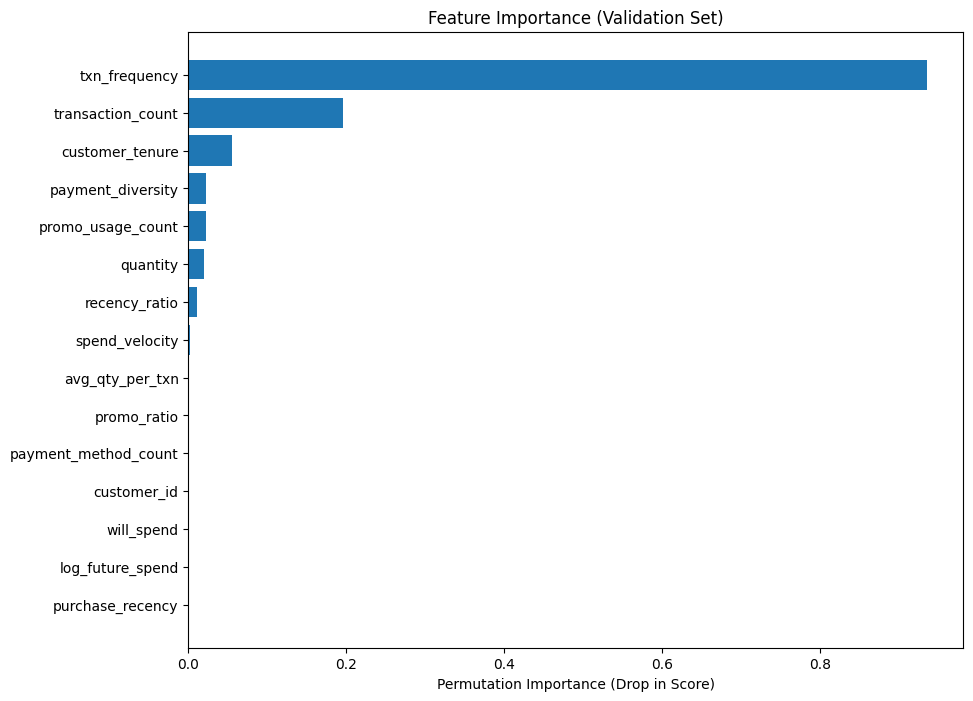

In [19]:
from sklearn.inspection import permutation_importance


y_valid_log = np.log1p(y_valid)


print("Calculating permutation importance... (this may take a moment)")
r = permutation_importance(
    pipeline,          
    X_valid,           
    y_valid_log,       
    n_repeats=10,       
    random_state=42,
    n_jobs=-1           
)

# Datafame to view resukts
importance_df = pd.DataFrame({
    'Feature': X_valid.columns,
    'Importance_Mean': r.importances_mean,
    'Importance_Std': r.importances_std
})


importance_df = importance_df.sort_values(by='Importance_Mean', ascending=False)

print("\nTop Features by Permutation Importance:")
print(importance_df.head(10))

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'][:15][::-1], importance_df['Importance_Mean'][:15][::-1])
plt.xlabel("Permutation Importance (Drop in Score)")
plt.title("Feature Importance (Validation Set)")
plt.show()